# Importing Necessary Libraries and Loading the Dataset

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sometime pandas doesn't show all the columns.
With pd. set_option('display. max_columns', None), pandas will display every single column, no matter how many there are.

In [201]:
pd.set_option('display.max_columns',None)

# Next, I load the dataset. 
In this case, I am working with the new.csv dataset, which contains Indian SMEs machines data.

In [239]:
df = pd.read_csv('new.csv')

# Dimension of the Data
To understand the size of the dataset, I use the .shape function:

In [203]:
df.shape

(228, 8)

# To get the first five rows, I use .head()

In [204]:
df.head()

,Factory_ID,Machine_ID,Energy_Consumption,Waste_Generated,Carbon_Emissions,Production_Capacity,Material_Usage,AI_Optimization_Applied
0,F19,M239,166,10,71,286,449,Yes
1,F3,M376,120,11,50,217,481,Yes
2,F2,M168,290,12,45,207,481,Yes
3,F7,M338,248,11,30,293,409,Yes
4,F4,M426,207,11,61,159,405,Yes


# Similarly, To get the last five rows, I use .tail()

In [205]:
df.tail()

,Factory_ID,Machine_ID,Energy_Consumption,Waste_Generated,Carbon_Emissions,Production_Capacity,Material_Usage,AI_Optimization_Applied
223,F11,M300,154,41,58,270,216,No
224,F16,M464,236,43,50,247,211,No
225,F12,M338,180,49,76,227,239,No
226,F10,M450,146,43,33,200,207,No
227,F13,M124,177,49,34,280,212,No


# To get a random sample of data, I use .sample(n), where n is the number of random rows to retrieve:

In [206]:
df.sample(5)

,Factory_ID,Machine_ID,Energy_Consumption,Waste_Generated,Carbon_Emissions,Production_Capacity,Material_Usage,AI_Optimization_Applied
120,F5,M140,142,24,78,241,355,No
180,F15,M468,294,29,73,234,248,No
158,F5,M220,240,31,44,162,319,No
63,F20,M446,183,30,53,173,477,Yes
212,F6,M352,125,48,77,155,288,No


# Data Type of Each Column:
I use .info() and .dtypes function here, which provides an overview of column names, data types, and missing values:

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Factory_ID               228 non-null    object
 1   Machine_ID               228 non-null    object
 2   Energy_Consumption       228 non-null    int64 
 3   Waste_Generated          228 non-null    int64 
 4   Carbon_Emissions         228 non-null    int64 
 5   Production_Capacity      228 non-null    int64 
 6   Material_Usage           228 non-null    int64 
 7   AI_Optimization_Applied  228 non-null    object
dtypes: int64(5), object(3)
memory usage: 14.4+ KB


In [208]:
df.dtypes

Factory_ID                 object
Machine_ID                 object
Energy_Consumption          int64
Waste_Generated             int64
Carbon_Emissions            int64
Production_Capacity         int64
Material_Usage              int64
AI_Optimization_Applied    object
dtype: object

# Checking Missing Values:
I use both .isna() and .isnull() function here.

In [209]:
df.isna().sum()

Factory_ID                 0
Machine_ID                 0
Energy_Consumption         0
Waste_Generated            0
Carbon_Emissions           0
Production_Capacity        0
Material_Usage             0
AI_Optimization_Applied    0
dtype: int64

In [210]:
df.isnull().sum()

Factory_ID                 0
Machine_ID                 0
Energy_Consumption         0
Waste_Generated            0
Carbon_Emissions           0
Production_Capacity        0
Material_Usage             0
AI_Optimization_Applied    0
dtype: int64

# Data Summary
To summarize numerical columns, I use .describe():

In [211]:
df.describe()

,Energy_Consumption,Waste_Generated,Carbon_Emissions,Production_Capacity,Material_Usage
count,228.000000,228.000000,228.000000,228.000000,228.000000
mean,206.000000,28.942982,54.942982,222.464912,357.052632
std,54.631485,10.238620,13.657590,42.835446,88.088196
min,102.000000,10.000000,30.000000,150.000000,200.000000
25%,160.000000,21.000000,44.750000,180.500000,281.000000
50%,215.000000,29.000000,54.500000,228.500000,360.500000
75%,250.250000,37.000000,67.000000,257.250000,436.250000
max,299.000000,49.000000,79.000000,298.000000,497.000000


# To print all the columns name.
I use .columns funtion here.

In [212]:
print(df.columns)

Index(['Factory_ID', 'Machine_ID', 'Energy_Consumption', 'Waste_Generated',
       'Carbon_Emissions', 'Production_Capacity', 'Material_Usage',
       'AI_Optimization_Applied'],
      dtype='object')


# Column Name Standardization
To ensure consistency and avoid errors during analysis, we clean and standardize the column names.
This improves readability and makes column names easier to use in coding, querying, and visualization.

In [213]:
# df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')

# Unique Values in Each Column
To check unique values in each column, I use .nunique:

In [214]:
df.nunique()

Factory_ID                  20
Machine_ID                 163
Energy_Consumption         137
Waste_Generated             38
Carbon_Emissions            50
Production_Capacity        121
Material_Usage             162
AI_Optimization_Applied      2
dtype: int64

# Checking for Duplicate Records

Duplicate entries in a dataset can lead to incorrect analysis and biased results.  
In this step, we use the `.duplicated()` function to detect duplicate rows and calculate their total count.

In [215]:
df.duplicated().sum()

np.int64(0)

# Removing Duplicate Records

Duplicate rows can negatively impact data analysis by introducing bias and inaccurate results.  
After identifying duplicate entries, we remove them to ensure data integrity and consistency.

The `drop_duplicates()` function is used to remove all duplicate rows from the dataset.

In [216]:
df.drop_duplicates( inplace = True)

# Checking Skewness of Numerical Features

Skewness measures the asymmetry of the distribution of numerical variables.

- A skewness value close to 0 indicates a symmetric distribution
- Positive skewness (> 0) means the data is right-skewed (tail on the right)
- Negative skewness (< 0) means the data is left-skewed (tail on the left)

This step helps in understanding data distribution and deciding whether transformations are required.

In [217]:
df.skew(numeric_only=True)

Energy_Consumption    -0.216355
Waste_Generated        0.098116
Carbon_Emissions       0.032636
Production_Capacity   -0.087692
Material_Usage        -0.118688
dtype: float64

In [218]:
df.skew(numeric_only = True).sort_values(ascending = False)

Waste_Generated        0.098116
Carbon_Emissions       0.032636
Production_Capacity   -0.087692
Material_Usage        -0.118688
Energy_Consumption    -0.216355
dtype: float64

I analyzed skewness to understand the distribution of features and determine whether data transformation was needed to improve model performance and statistical validity.

# Checking Kurtosis of Numerical Features

Kurtosis measures the "tailedness" or peak of the data distribution.

- Kurtosis ≈ 0 → Normal distribution (Mesokurtic)
- Kurtosis > 0 → More peaked with heavy tails (Leptokurtic)
- Kurtosis < 0 → Flatter distribution with light tails (Platykurtic)

This helps in understanding the presence of outliers and the overall shape of the data distribution.

In [219]:
df.kurt(numeric_only = True)

Energy_Consumption    -1.063563
Waste_Generated       -0.834022
Carbon_Emissions      -1.121868
Production_Capacity   -1.222018
Material_Usage        -1.278852
dtype: float64

# Insight
Since all features are platykurtic, extreme outliers are less likely to impact the model. 
Therefore, aggressive outlier treatment may not be required.

# Checking Kurtosis using Graph

Kurtosis: -1.063563410516507


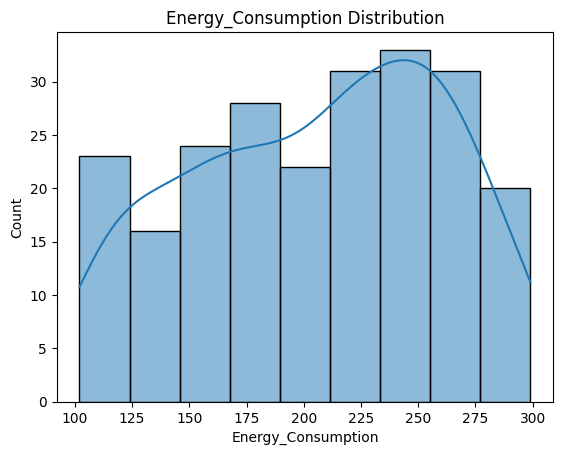

Kurtosis: -0.8340215907113984


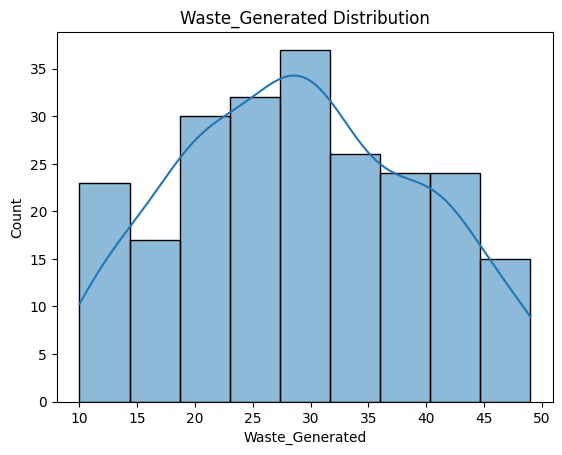

Kurtosis: -1.2788516060612707


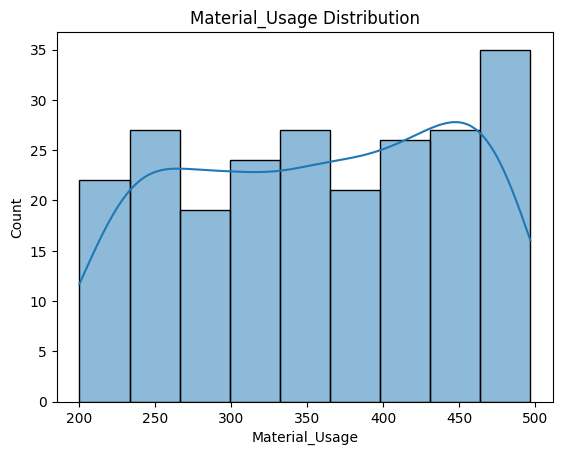

Kurtosis: -1.121868211703744


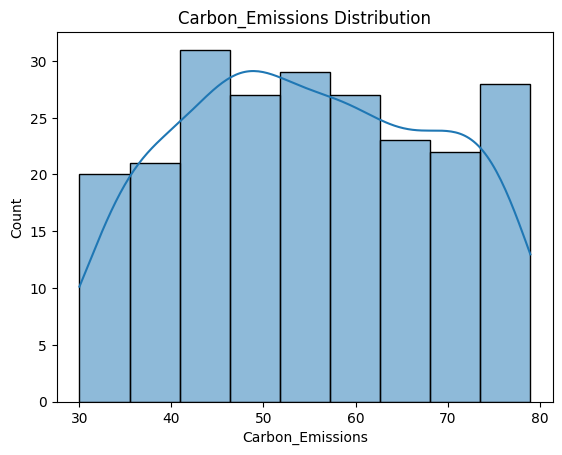

Kurtosis: -1.2220178683931926


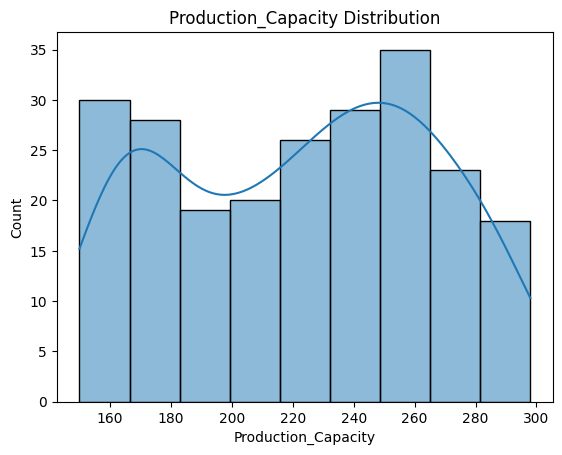

In [220]:
col = 'Energy_Consumption'

print("Kurtosis:", df[col].kurt())

sns.histplot(df[col], kde=True)
plt.title(f"{col} Distribution")
plt.show()


kol = 'Waste_Generated'

print("Kurtosis:", df[kol].kurt())

sns.histplot(df[kol], kde=True)
plt.title(f"{kol} Distribution")
plt.show()


mu = 'Material_Usage'

print("Kurtosis:", df[mu].kurt())

sns.histplot(df[mu], kde=True)
plt.title(f"{mu} Distribution")
plt.show()

ce = 'Carbon_Emissions'
print("Kurtosis:", df[ce].kurt())

sns.histplot(df[ce], kde=True)
plt.title(f"{ce} Distribution")
plt.show()


pc = 'Production_Capacity'
print("Kurtosis:", df[pc].kurt())

sns.histplot(df[pc], kde=True)
plt.title(f"{pc} Distribution")
plt.show()

# Handling Missing Values in 'Waste_Generated'

Missing values can affect the accuracy of analysis and machine learning models.  
To handle this, I replace missing values in the 'Waste_Generated' column with the mean of the column.

In [221]:
df['Waste_Generated'].fillna(df['Waste_Generated'].mean(), inplace = True)

C:\Users\user\AppData\Local\Temp\ipykernel_30840\461240510.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





# Outlier Detection using IQR Method (Carbon_Emissions)

To identify outliers in the 'Carbon_Emissions' variable, the Interquartile Range (IQR) method is used.



In [222]:
Q1 = df['Carbon_Emissions'].quantile(0.25)
Q3 = df['Carbon_Emissions'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_outliers = df[(df['Carbon_Emissions'] < lower) | (df['Carbon_Emissions'] > upper)]
print(df_outliers)

Empty DataFrame
Columns: [Factory_ID, Machine_ID, Energy_Consumption, Waste_Generated, Carbon_Emissions, Production_Capacity, Material_Usage, AI_Optimization_Applied]
Index: []


#### Outlier Analysis Result
The IQR method did not detect any outliers in the `Carbon_Emissions` feature.
All values fall within the acceptable range. 

# Machine Distribution Across Factories

To analyze how machines are distributed across different factories, I count the number of machines associated with each Factory_ID.

- `value_counts()` is used to count occurrences
- The data is then visualized using a bar chart

C:\Users\user\AppData\Local\Temp\ipykernel_30840\2938500441.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




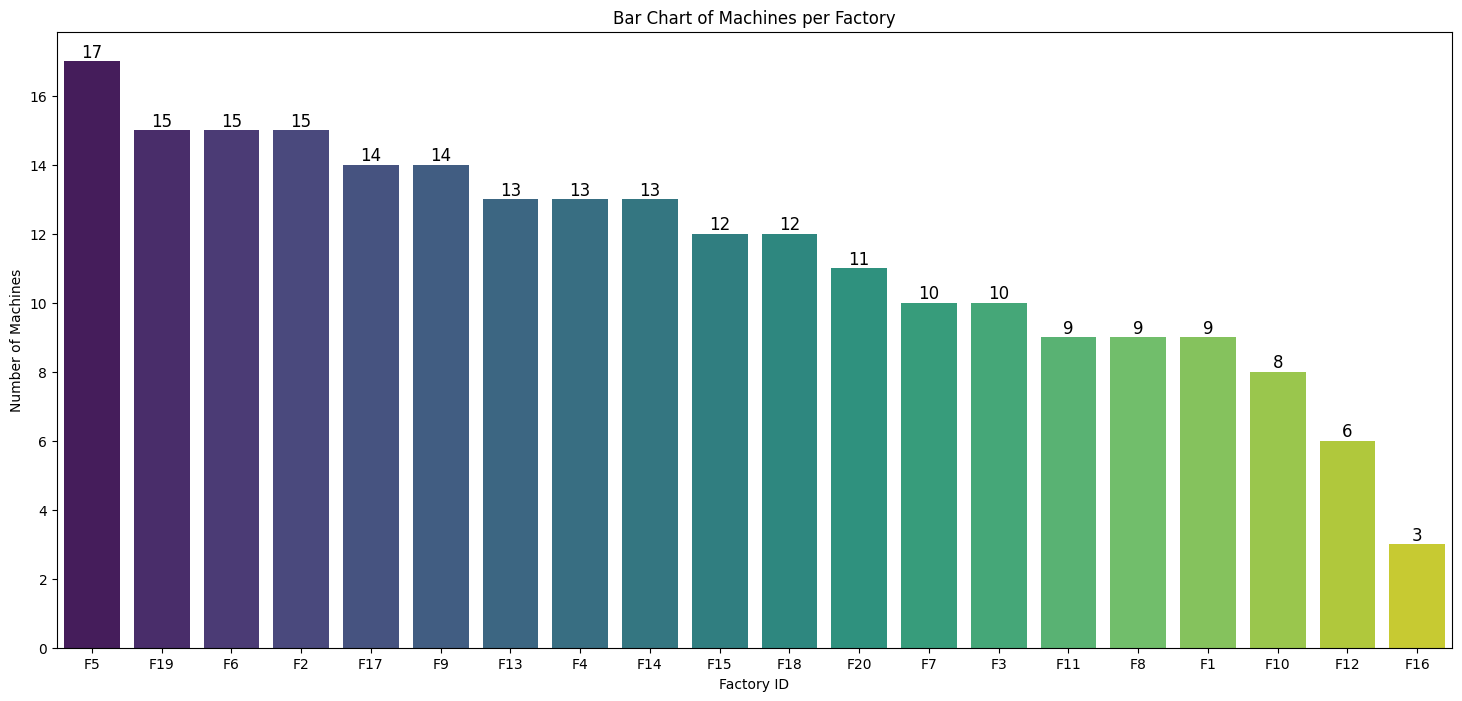

In [224]:
machine_counts = df["Factory_ID"].value_counts().rename_axis("Factory_ID").reset_index(name="Machine_Count")

plt.figure(figsize=(18, 8))
ax = sns.barplot(x="Factory_ID", y="Machine_Count", data=machine_counts, palette="viridis")

for container in ax.containers:
    ax.bar_label(container, fontsize=12)

plt.xlabel("Factory ID")
plt.ylabel("Number of Machines")
plt.title("Bar Chart of Machines per Factory")
plt.show()

# Convert categorical to binary values:
I change categiorical values of column `AI_Optimization_Applied` to binary values (1 = Yes, 0 = No)

In [225]:
df["AI_Optimization_Applied"] = df["AI_Optimization_Applied"].map({"Yes": 1, "No": 0})

# I use Bar Chart to show  how many `AI-Applied vs. Non-AI` Machines are available

C:\Users\user\AppData\Local\Temp\ipykernel_30840\3579862751.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




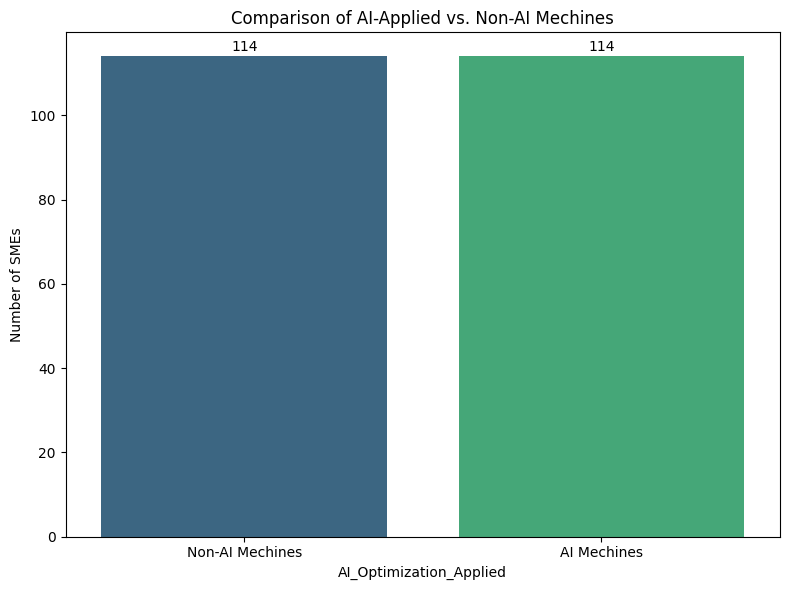

In [226]:
ai_counts = df["AI_Optimization_Applied"].value_counts()
plt.figure(figsize=(8, 6))
barplot = sns.barplot(x=ai_counts.index, y=ai_counts.values, palette="viridis")

for i, value in enumerate(ai_counts.values):
    plt.text(i, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

plt.xticks(ticks=[0, 1], labels=["Non-AI Mechines", "AI Mechines"])
plt.ylabel("Number of SMEs")
plt.title("Comparison of AI-Applied vs. Non-AI Mechines")
plt.tight_layout()
plt.show()

# Outlier Detection using Box Plots

Box plots are used to visually identify the presence of outliers in numerical features.

Box plots display:
- Median
- Interquartile Range (IQR)
- Potential outliers

This helps in validating statistical findings from skewness, kurtosis, and IQR analysis.

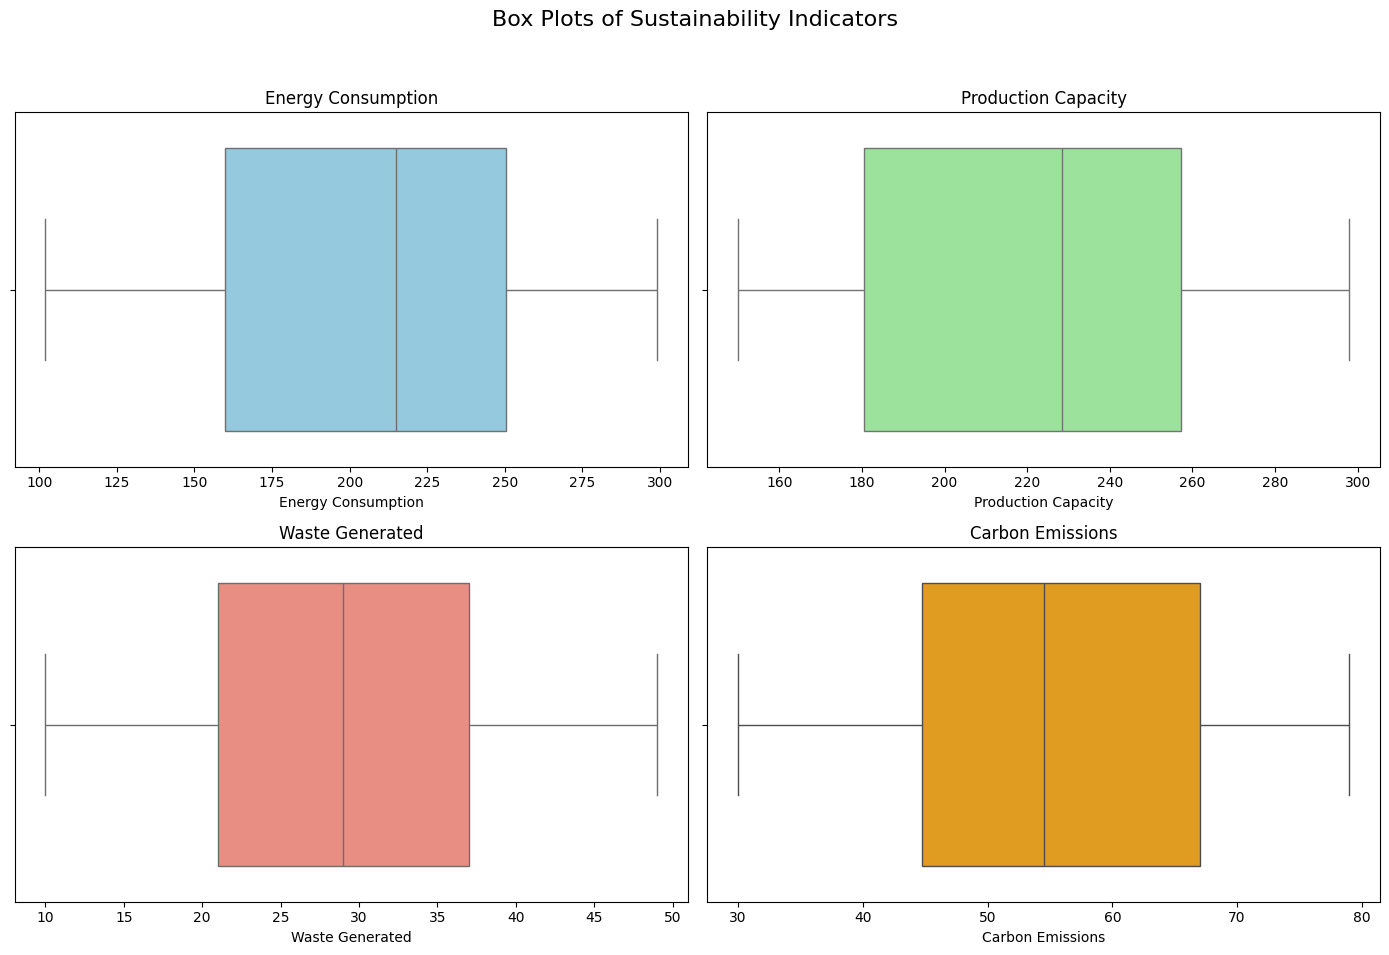

In [227]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Box Plots of Sustainability Indicators", fontsize=16)

# Plot 1
sns.boxplot(x=df['Energy_Consumption'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("Energy Consumption")
axes[0, 0].set_xlabel("Energy Consumption")

# Plot 2
sns.boxplot(x=df['Production_Capacity'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title("Production Capacity")
axes[0, 1].set_xlabel("Production Capacity")

# Plot 3
sns.boxplot(x=df['Waste_Generated'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title("Waste Generated")
axes[1, 0].set_xlabel("Waste Generated")

# Plot 4
sns.boxplot(x=df['Carbon_Emissions'], ax=axes[1, 1], color='orange')
axes[1, 1].set_title("Carbon Emissions")
axes[1, 1].set_xlabel("Carbon Emissions")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Pairplot with AI vs Non-AI Comparison

To analyze relationships between sustainability indicators and AI adoption, 
a pairplot is created with hue representing AI usage.

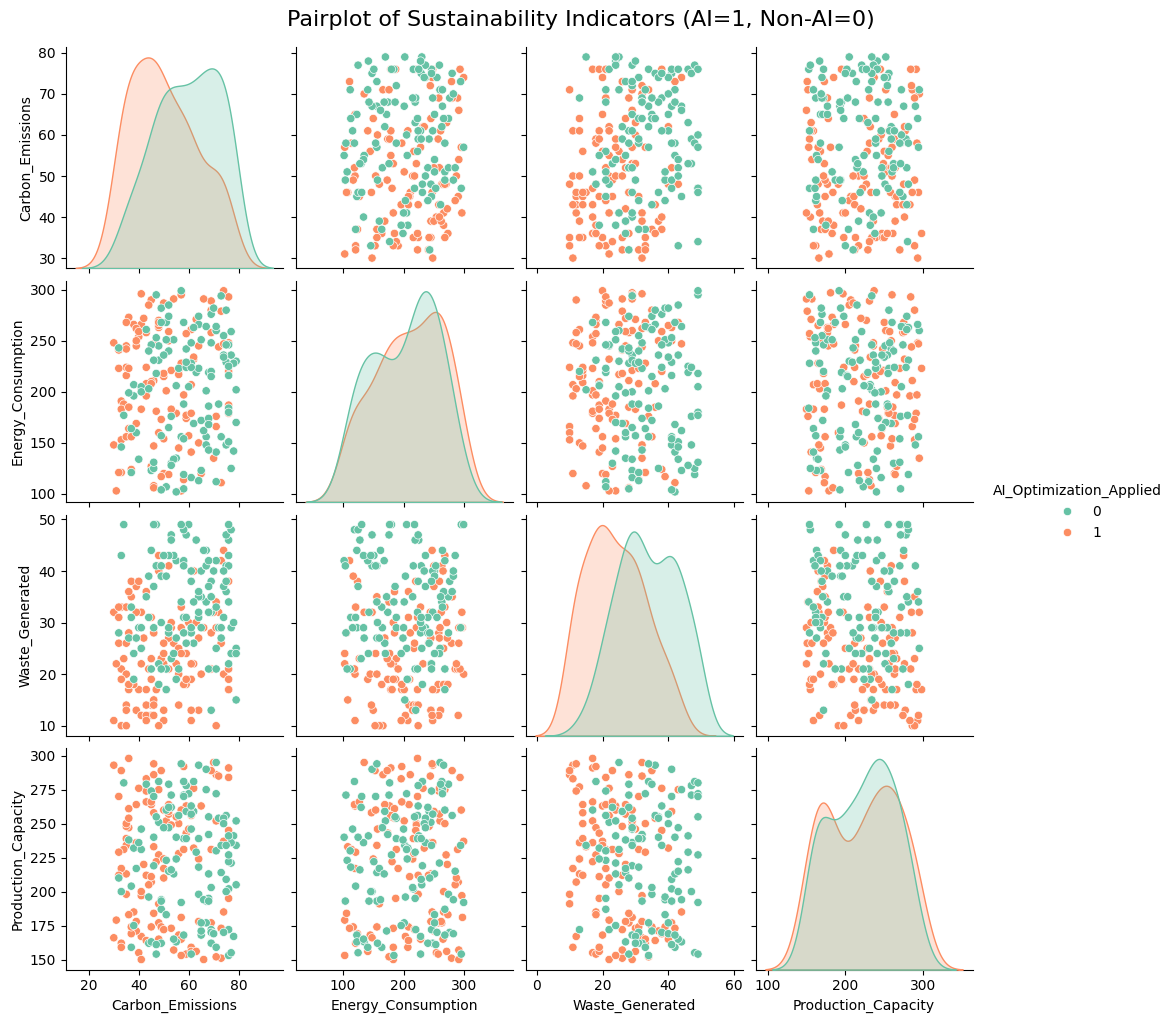

In [228]:
pairplot_cols = [
    'Carbon_Emissions',
    'Energy_Consumption',
    'Waste_Generated',
    'Production_Capacity',
    'AI_Optimization_Applied'
]

df_pairplot = df[pairplot_cols]

sns.pairplot(
    df_pairplot,
    hue='AI_Optimization_Applied',
    palette='Set2',
    diag_kind='kde'
)

plt.suptitle(
    'Pairplot of Sustainability Indicators (AI=1, Non-AI=0)',
    fontsize=16,
    y=1.02
)

plt.show()

In [229]:
ai_machines = df[df["AI_Optimization_Applied"] == 1]
non_ai_machines = df[df["AI_Optimization_Applied"] == 0]

print("Variance of AI Carbon Emissions:", ai_machines["Carbon_Emissions"].var())
print("Variance of Non-AI Carbon Emissions:", non_ai_machines["Carbon_Emissions"].var())

Variance of AI Carbon Emissions: 172.30779382083526
Variance of Non-AI Carbon Emissions: 160.34063033690418


# Statistical Comparison: AI vs Non-AI SMEs

An independent t-test was conducted to compare sustainability indicators 
between AI-enabled and non-AI SMEs.

In [230]:
from scipy.stats import ttest_ind

ai_machines = df[df["AI_Optimization_Applied"] == 1]
non_ai_machines = df[df["AI_Optimization_Applied"] == 0]

columns = [
    "Energy_Consumption",
    "Waste_Generated",
    "Carbon_Emissions",
    "Production_Capacity",
    "Material_Usage"
]

results = []

for col in columns:
    var_ai = ai_machines[col].var()
    var_non_ai = non_ai_machines[col].var()
    
    t_stat, p_value = ttest_ind(
        ai_machines[col],
        non_ai_machines[col],
        equal_var=False
    )
  
    results.append({
        "Feature": col,
        "AI Variance": var_ai,
        "Non-AI Variance": var_non_ai,
        "T-Statistic": t_stat,
        "P-Value": p_value
    })

import pandas as pd
results_df = pd.DataFrame(results)

results_df

,Feature,AI Variance,Non-AI Variance,T-Statistic,P-Value
0,Energy_Consumption,3074.119624,2892.650598,1.045166,2.970640e-01
1,Waste_Generated,79.424080,82.387207,-8.253702,1.278895e-14
2,Carbon_Emissions,172.307794,160.340630,-5.345712,2.200811e-07
3,Production_Capacity,2056.444729,1629.521580,-0.037024,9.704990e-01
4,Material_Usage,4649.272861,5871.173187,10.433373,5.197774e-21


# Conclusion:
AI adoption shows a statistically significant impact on:
- Waste Generated
- Carbon Emissions
- Material Usage

However, no significant effect is observed in:
- Energy Consumption
- Production Capacity

# Displaying all unique Factories and Machines

In [231]:
unique_factory_count = df["Factory_ID"].nunique()

unique_factorys = df["Factory_ID"].unique()

print(f"Total Unique Factory_IDs: {unique_factory_count}")
print("List of Unique Factory_IDs:")
print(unique_factorys)

Total Unique Factory_IDs: 20
List of Unique Factory_IDs:
['F19' 'F3' 'F2' 'F7' 'F4' 'F9' 'F20' 'F13' 'F17' 'F5' 'F8' 'F12' 'F14'
 'F15' 'F10' 'F6' 'F1' 'F11' 'F18' 'F16']


In [232]:
unique_machine_count = df["Machine_ID"].nunique()

unique_machines = df["Machine_ID"].unique()

print(f"Total Unique Machine_IDs: {unique_machine_count}")
print("List of Unique Machine_IDs:")
print(unique_machines)

Total Unique Machine_IDs: 163
List of Unique Machine_IDs:
['M239' 'M376' 'M168' 'M338' 'M426' 'M162' 'M449' 'M447' 'M255' 'M171'
 'M339' 'M287' 'M200' 'M372' 'M198' 'M153' 'M143' 'M468' 'M383' 'M114'
 'M152' 'M205' 'M351' 'M296' 'M445' 'M317' 'M474' 'M160' 'M297' 'M470'
 'M161' 'M451' 'M215' 'M291' 'M137' 'M189' 'M140' 'M454' 'M192' 'M314'
 'M108' 'M157' 'M134' 'M252' 'M128' 'M164' 'M322' 'M220' 'M191' 'M343'
 'M135' 'M227' 'M133' 'M364' 'M446' 'M132' 'M218' 'M121' 'M226' 'M228'
 'M415' 'M326' 'M456' 'M211' 'M112' 'M244' 'M125' 'M438' 'M221' 'M271'
 'M402' 'M138' 'M391' 'M332' 'M289' 'M127' 'M435' 'M485' 'M202' 'M352'
 'M492' 'M448' 'M247' 'M307' 'M194' 'M180' 'M232' 'M379' 'M417' 'M175'
 'M334' 'M174' 'M363' 'M366' 'M315' 'M102' 'M487' 'M285' 'M263' 'M471'
 'M257' 'M385' 'M196' 'M405' 'M311' 'M478' 'M230' 'M301' 'M425' 'M473'
 'M279' 'M101' 'M320' 'M319' 'M267' 'M355' 'M416' 'M235' 'M346' 'M330'
 'M155' 'M243' 'M384' 'M392' 'M107' 'M349' 'M493' 'M437' 'M276' 'M259'
 'M242' 'M472' 'M31

# Comparative Analysis: AI vs Non-AI SMEs

To evaluate the impact of AI adoption on sustainability indicators, 
a comparative visualization is performed using:

- Boxplots: Compare distribution and median values
- Histograms: Compare frequency distribution

C:\Users\user\AppData\Local\Temp\ipykernel_30840\4127226673.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_30840\4127226673.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_30840\4127226673.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\user\AppData\Local\Temp\ipykernel_30840\4127226673.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same ef

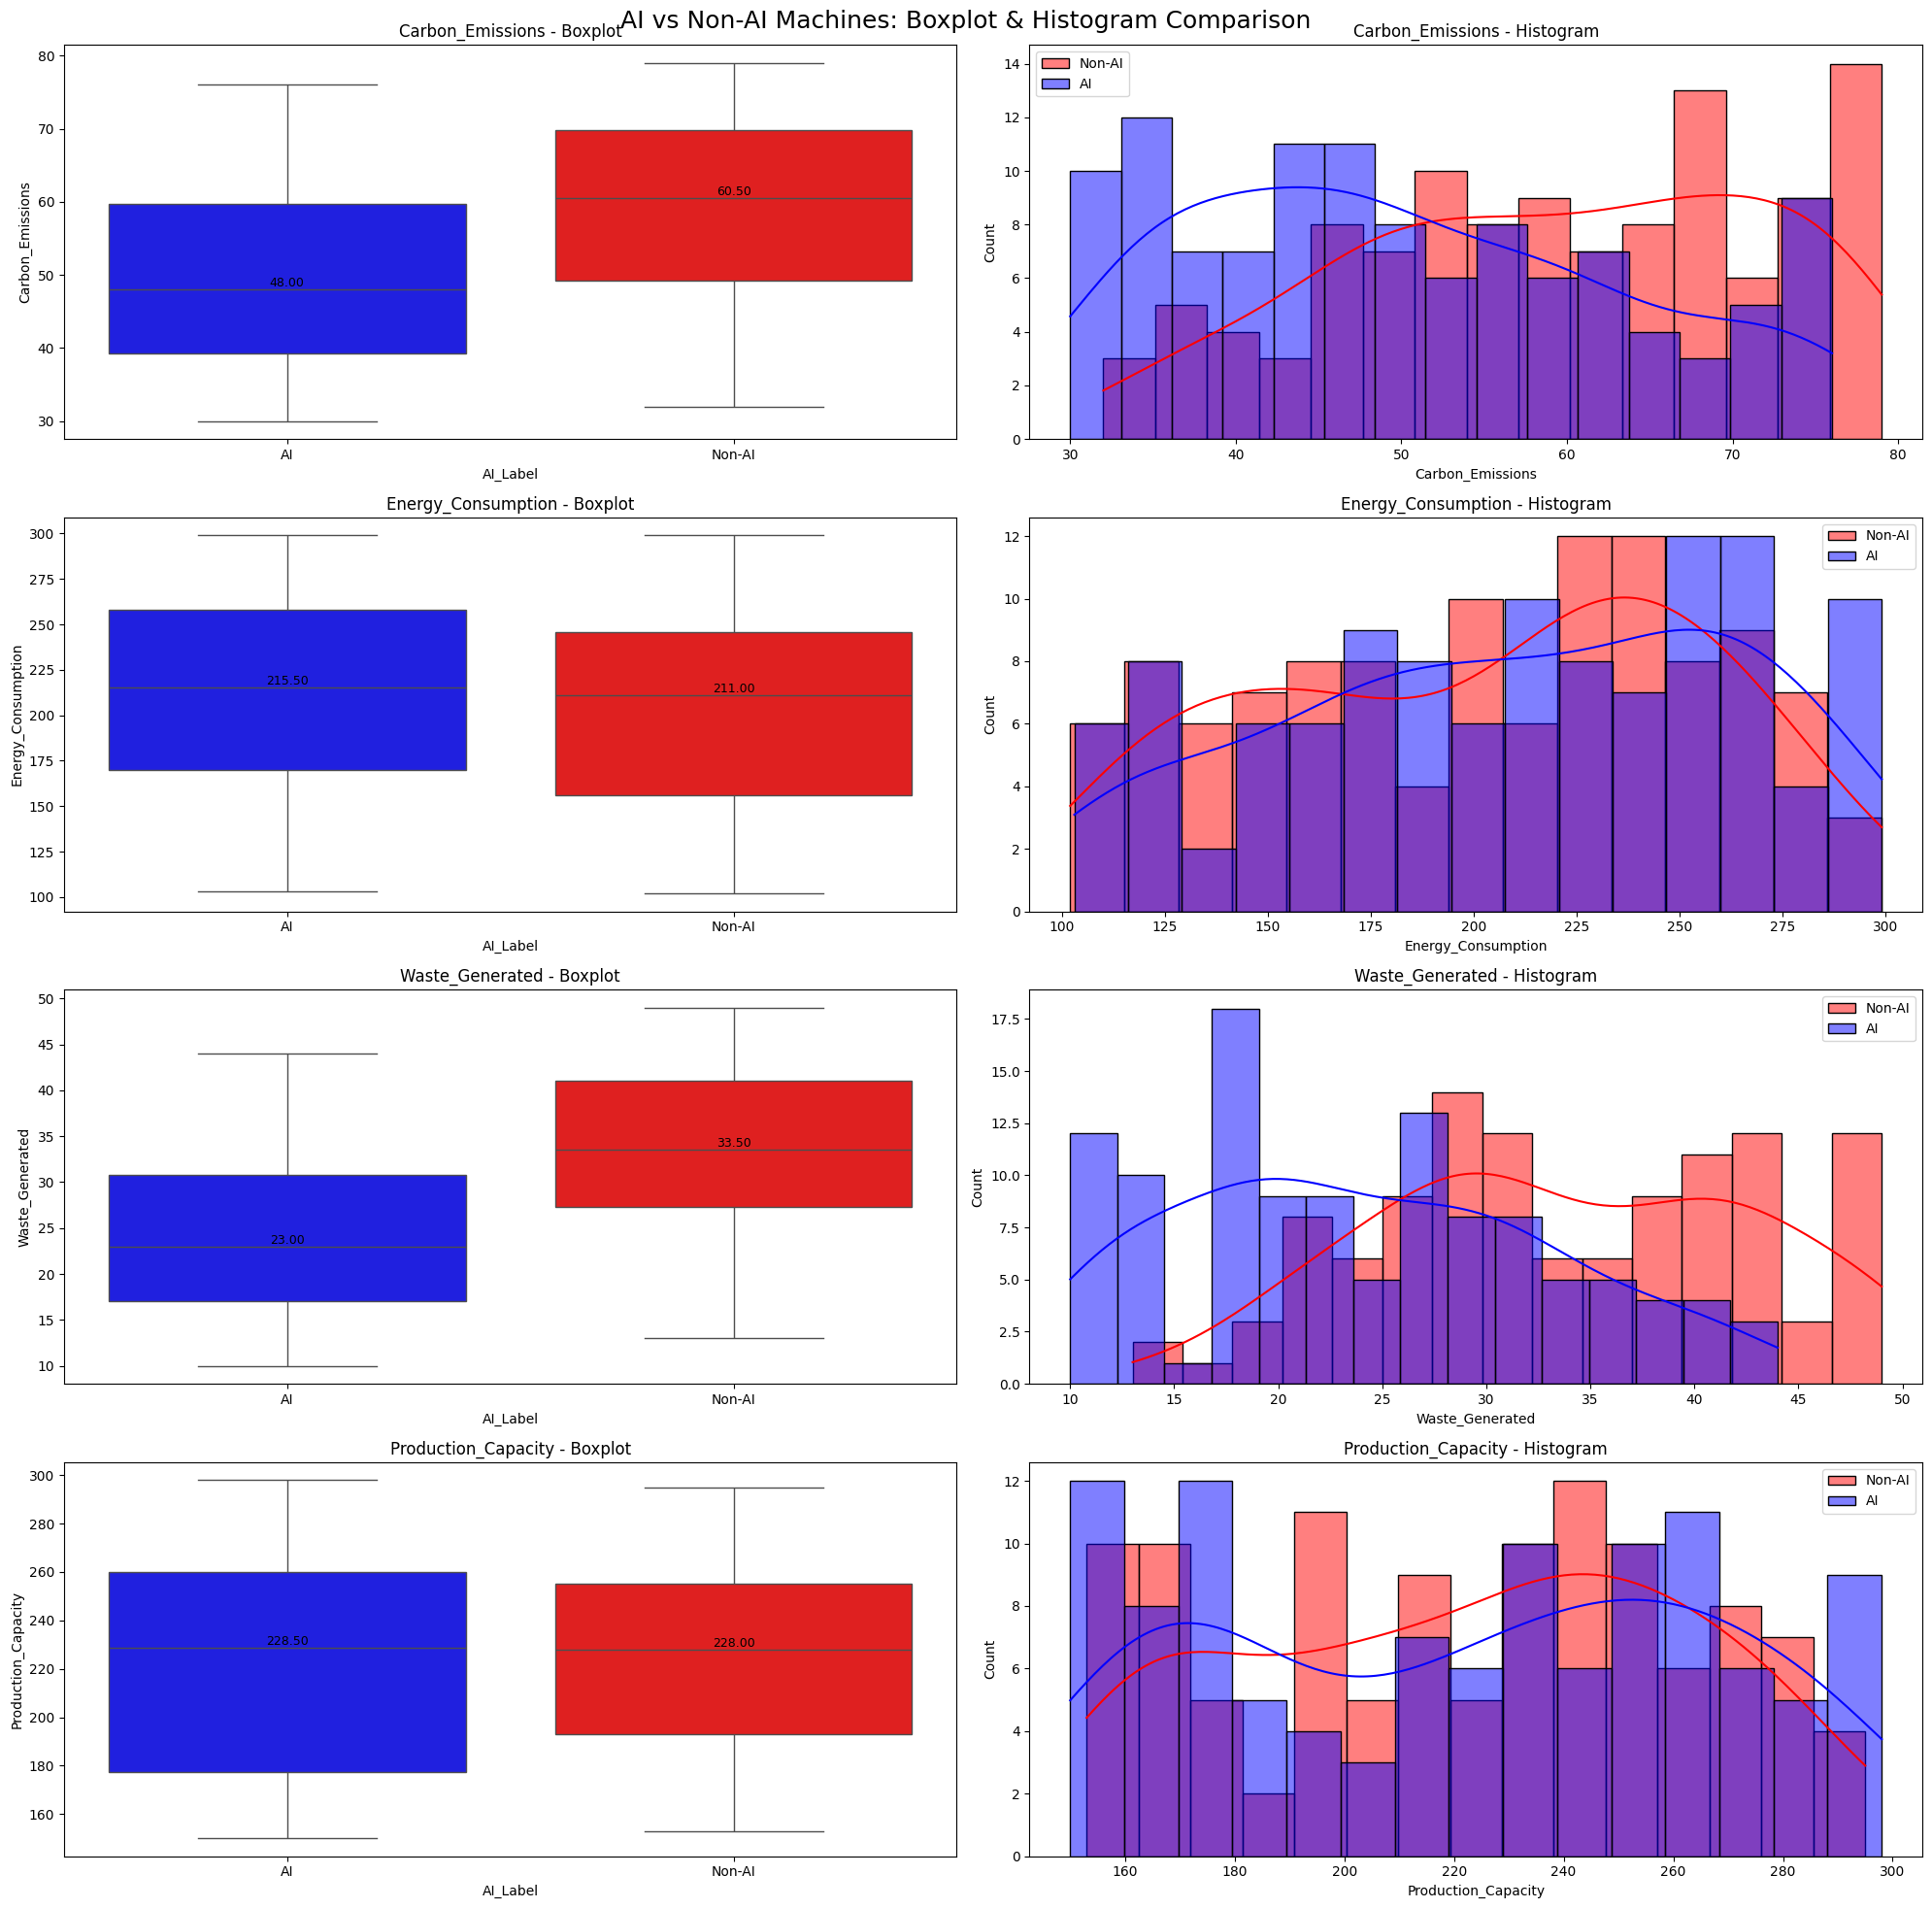

In [236]:
metrics = ["Carbon_Emissions", "Energy_Consumption", "Waste_Generated", "Production_Capacity"]

df["AI_Label"] = df["AI_Optimization_Applied"].map({0: "Non-AI", 1: "AI"})

ai = df[df["AI_Label"] == "AI"]
non_ai = df[df["AI_Label"] == "Non-AI"]

fig, axes = plt.subplots(nrows=len(metrics), ncols=2, figsize=(20, 20))
fig.suptitle("AI vs Non-AI Machines: Boxplot & Histogram Comparison", fontsize=18)

for i, metric in enumerate(metrics):

    # Boxplot
    sns.boxplot(
        x="AI_Label", y=metric, data=df,
        palette={"Non-AI": "red", "AI": "blue"}, ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{metric} - Boxplot")

    medians = df.groupby("AI_Label")[metric].median()
    for tick, label in enumerate(df["AI_Label"].unique()):
        axes[i, 0].text(tick, medians[label], f'{medians[label]:.2f}',
                        ha='center', va='bottom', fontsize=9, color='black')

    sns.histplot(non_ai[metric], color="red", label="Non-AI", kde=True, bins=15, ax=axes[i, 1])
    sns.histplot(ai[metric], color="blue", label="AI", kde=True, bins=15, ax=axes[i, 1])

    axes[i, 1].set_title(f"{metric} - Histogram")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

# Correlation Analysis of AI Adoption and Sustainability Indicators

A correlation heatmap is used to examine the relationship between AI adoption 
and key sustainability metrics.

The correlation coefficient ranges from -1 to +1:
- +1 → Strong positive relationship
- -1 → Strong negative relationship
- 0 → No relationship

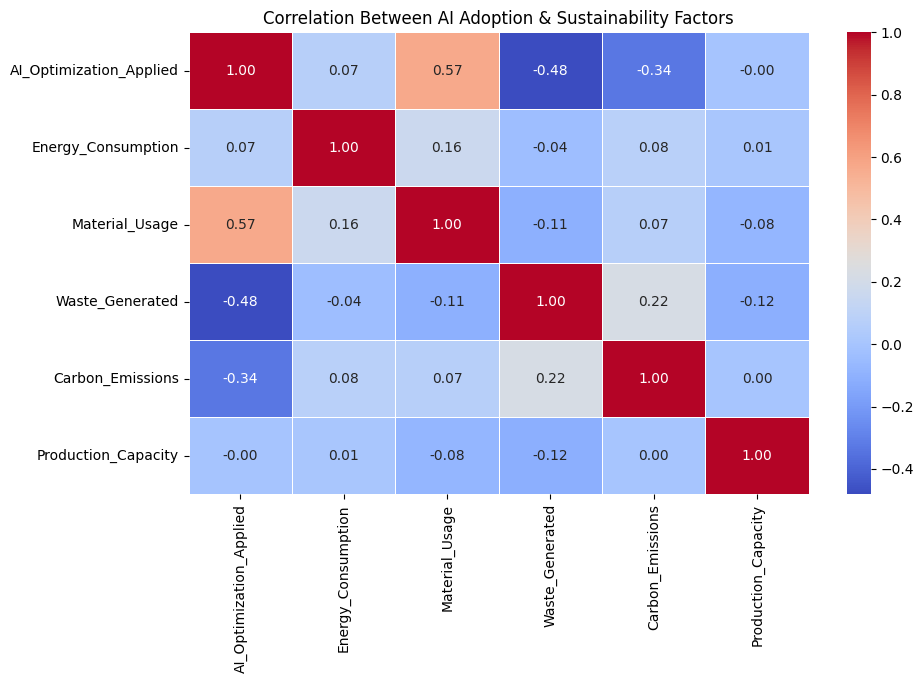

In [237]:
correlation_columns = ["AI_Optimization_Applied", "Energy_Consumption", "Material_Usage",
                       "Waste_Generated", "Carbon_Emissions", "Production_Capacity"]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between AI Adoption & Sustainability Factors")
plt.show()

# Correlation Insights

- Material Usage (0.57) → AI has strong impact  
- Waste Generated (-0.48) → AI reduces waste  
- Carbon Emissions (-0.34) → AI reduces emissions  
- Energy Consumption (0.07) → No significant impact  
- Production Capacity (~0) → No impact  


# Mean Comparison: AI vs Non-AI SMEs

This chart compares the average values of key sustainability metrics 
between AI-adopted and non-AI SMEs.

It helps identify how AI impacts:
- Carbon Emissions
- Production Capacity
- Energy Consumption
- Waste Generated

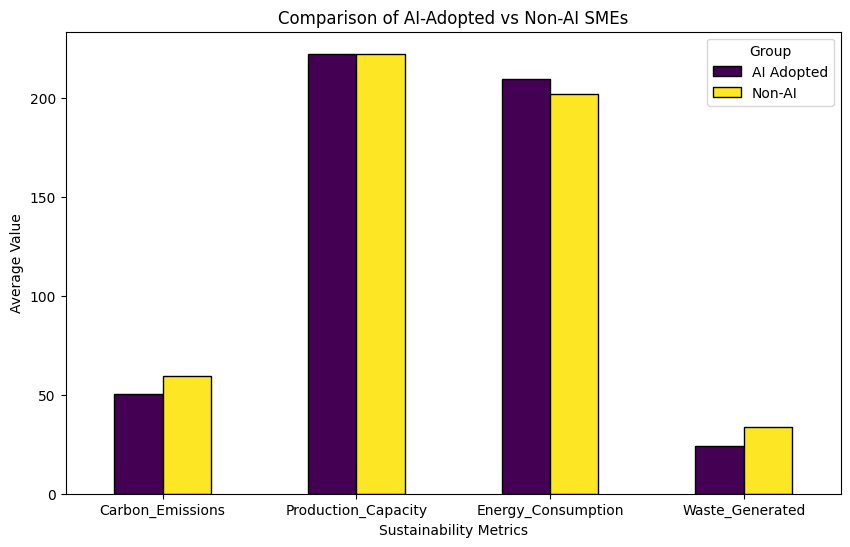

In [243]:
df = pd.read_csv('new.csv')
df["AI_Optimization_Applied"] = df["AI_Optimization_Applied"].map({"Yes": 1, "No": 0})

ai_adopted = df[df["AI_Optimization_Applied"] == 1]
non_ai_adopted = df[df["AI_Optimization_Applied"] == 0]

metrics = ["Carbon_Emissions", "Production_Capacity", "Energy_Consumption", "Waste_Generated"]

ai_means = ai_adopted[metrics].mean()
non_ai_means = non_ai_adopted[metrics].mean()

df_means = pd.DataFrame({
    "AI Adopted": ai_means,
    "Non-AI": non_ai_means
})

df_means.plot(kind="bar", figsize=(10, 6), colormap="viridis", edgecolor="black")

plt.xlabel("Sustainability Metrics")
plt.ylabel("Average Value")
plt.title("Comparison of AI-Adopted vs Non-AI SMEs")
plt.xticks(rotation=0)
plt.legend(title="Group")
plt.show()

# Insights:

- AI SMEs have **lower carbon emissions**  
- AI SMEs have **lower waste generation**  
- AI SMEs have **slightly lower energy consumption**  
- Production capacity is **almost the same**  

### Conclusion:
AI improves **efficiency (less waste & emissions)**, but does not significantly increase **production capacity**.